# Combining all results

In [78]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from pathlib import Path
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import ttest_rel
import utils as ut

In [79]:
colors_seg = ['#FFC107', '#1E88E5']

## Loading and merging data

In [80]:
df_fd_BOB = pd.read_csv('outputs/BOB_fd_results.csv')
df_fd_fs_seg = pd.read_csv('outputs/BOB_fd_results_freesurfer-seg.csv')
df_seg_metrics = pd.read_csv('outputs/segmentation_metrics.csv')
df_seg_volumnes = pd.read_csv('outputs/segmentation_volumes.csv')

df_fd_samseg = pd.read_csv('outputs/samseg/BOB_fd_results_samseg.csv')
df_seg_metrics_samseg = pd.read_csv('outputs/samseg/segmentation_metrics_samseg.csv')
df_seg_volumnes_samseg = pd.read_csv('outputs/samseg/segmentation_volumes_samseg.csv')


In [81]:
df_seg_metrics_wb = pd.read_csv('outputs/whole_brain_csf_metrics.csv')
df_seg_metrics_all = pd.concat([df_seg_metrics, df_seg_metrics_wb], ignore_index=True, sort=False)
df_seg_metrics_all#.head()

,participant_id,session_id,label,name,metric,value
0,sub-116056,ses-3mo,2.0,Left-Cerebral-White-Matter,Dice,0.742034
1,sub-116056,ses-3mo,2.0,Left-Cerebral-White-Matter,IoU,0.589868
2,sub-116056,ses-3mo,2.0,Left-Cerebral-White-Matter,Hausdorff,68.432448
3,sub-116056,ses-3mo,2.0,Left-Cerebral-White-Matter,HD95,2.828427
4,sub-116056,ses-3mo,2.0,Left-Cerebral-White-Matter,MI,0.054265
...,...,...,...,...,...,...
13861,sub-993015,ses-5mo,NaN,whole_brain_minus_CSF,IoU,0.921247
13862,sub-993015,ses-5mo,NaN,whole_brain_minus_CSF,Hausdorff,8.062258
13863,sub-993015,ses-5mo,NaN,whole_brain_minus_CSF,HD95,2.236068
13864,sub-993015,ses-5mo,NaN,whole_brain_minus_CSF,MI,0.273229


In [82]:
df_seg_metrics_wb2 = pd.read_csv('outputs/samseg/whole_brain_csf_metrics_samseg.csv')
df_seg_metrics_all2 = pd.concat([df_seg_metrics_samseg, df_seg_metrics_wb2], ignore_index=True, sort=False)
df_seg_metrics_all2

,participant_id,session_id,label,name,metric,value
0,sub-381606,ses-2mo,51.0,Right-Putamen,Dice,0.177127
1,sub-381606,ses-2mo,51.0,Right-Putamen,IoU,0.097169
2,sub-381606,ses-2mo,51.0,Right-Putamen,Hausdorff,18.547237
3,sub-381606,ses-2mo,51.0,Right-Putamen,HD95,11.364407
4,sub-381606,ses-2mo,51.0,Right-Putamen,MI,0.000478
...,...,...,...,...,...,...
16327,sub-726893,ses-5mo,NaN,whole_brain_minus_ALL,IoU,0.019372
16328,sub-726893,ses-5mo,NaN,whole_brain_minus_ALL,Hausdorff,56.727418
16329,sub-726893,ses-5mo,NaN,whole_brain_minus_ALL,HD95,22.090721
16330,sub-726893,ses-5mo,NaN,whole_brain_minus_ALL,MI,0.000237


In [83]:
common_names = pd.Series(list(set(df_fd_BOB['name'].unique()) & set(df_fd_fs_seg['name'].unique()) & set(df_fd_samseg['name'].unique())))
common_names

0                     4th-Ventricle
1                  Left-Hippocampus
2                    Right-Amygdala
3                 Left-Inf-Lat-Vent
4                   Right-VentralDC
5                     Left-Thalamus
6                 Right-Hippocampus
7                     Left-Pallidum
8      Left-Cerebellum-White-Matter
9            Left-Cerebellum-Cortex
10                     Left-Putamen
11                   Right-Thalamus
12                    Right-Putamen
13                     Left-Caudate
14       Left-Cerebral-White-Matter
15                       Brain-Stem
16                              CSF
17                   Right-Pallidum
18                    Left-Amygdala
19             Left-Cerebral-Cortex
20    Right-Cerebellum-White-Matter
21          Right-Lateral-Ventricle
22               Right-Inf-Lat-Vent
23             Right-Accumbens-area
24                      whole_brain
25          Right-Cerebellum-Cortex
26           Left-Lateral-Ventricle
27              Left-Accumbe

In [84]:
# common_names = pd.Series(list(set(df_fd_BOB['name'].unique()) & set(df_fd_fs_seg['name'].unique())))
df_fd_BOB_common = df_fd_BOB[df_fd_BOB['name'].isin(common_names)]
df_fd_fs_seg_common = df_fd_fs_seg[df_fd_fs_seg['name'].isin(common_names)]
df_fd_samseg_common = df_fd_samseg[df_fd_samseg['name'].isin(common_names)]

df_fd_BOB_common = df_fd_BOB_common.rename(columns={'fd': 'fd_BOB'})
df_fd_fs_seg_common = df_fd_fs_seg_common.rename(columns={'fd': 'fd_SynthSeg'})
df_fd_samseg_common = df_fd_samseg_common.rename(columns={'fd': 'fd_Samseg'})

df_fd_merged = pd.merge(
    df_fd_BOB_common[['participant_id', 'session_id', 'name', 'fd_BOB','age','sex']],
    df_fd_fs_seg_common[['participant_id', 'session_id', 'name', 'fd_SynthSeg']],
    on=['participant_id', 'session_id', 'name'],
    how='inner'
)

df_fd_merged = pd.merge(
    df_fd_merged,
    df_fd_samseg_common[['participant_id', 'session_id', 'name', 'fd_Samseg']],
    on=['participant_id', 'session_id', 'name'],
    how='inner'
)
df_fd_merged.head()

,participant_id,session_id,name,fd_BOB,age,sex,fd_SynthSeg,fd_Samseg
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8088,2.8645
1,sub-116056,ses-3mo,Left-Cerebral-White-Matter,2.4704,3.6,Male,2.4882,2.5723
2,sub-116056,ses-3mo,Left-Cerebral-Cortex,2.4475,3.6,Male,2.4989,2.3986
3,sub-116056,ses-3mo,Left-Lateral-Ventricle,1.5052,3.6,Male,1.4089,2.2229
4,sub-116056,ses-3mo,Left-Inf-Lat-Vent,1.3861,3.6,Male,1.1902,1.7720


In [85]:
df_fd_wb = pd.read_csv('outputs/fd_wb_minus_csf.csv')
df_fd_wb_samseg = pd.read_csv('outputs/samseg/fd_wb_minus_csf_samseg.csv')
df_fd_wb_samseg2 = pd.read_csv('outputs/samseg/fd_wb_minus_all_samseg.csv')
# Extract age and sex
meta = (
    df_fd_merged[["participant_id","session_id","age","sex"]]
    .drop_duplicates()  # one row per unique (participant_id,session_id)
)

# Left‐join
df_fd_wb_enriched = df_fd_wb.merge(
    meta,
    on=["participant_id","session_id"],
    how="left"
)
df_fd_wb_enriched.drop(columns=['label', 'min_box_size','max_box_size'], inplace=True)

# Merge in samseg data (adding suffixes to distinguish overlapping column names)
df_fd_wb_enriched = df_fd_wb_enriched.merge(
    df_fd_wb_samseg,
    on=["participant_id", "session_id"],
    how="left",
    suffixes=('', '_samseg')
)

df_fd_wb_enriched = df_fd_wb_enriched.merge(
    df_fd_wb_samseg2,
    on=["participant_id", "session_id"],
    how="left",
    suffixes=('', '_2')
)
# Select only the desired columns
df_fd_wb_enriched = df_fd_wb_enriched[
    [
        'participant_id',
        'session_id',
        'name',
        'fd_BOB',
        'fd_SynthSeg',
        'fd_Samseg',
        'fd_Samseg_2',
        'age',
        'sex'
    ]
]

# Preview the cleaned DataFrame
df_fd_wb_enriched.head()

,participant_id,session_id,name,fd_BOB,fd_SynthSeg,fd_Samseg,fd_Samseg_2,age,sex
0,sub-116056,ses-3mo,whole_brain_minus_CSF,2.7598,2.7760,2.8143,2.2951,3.6,Male
1,sub-116845,ses-3mo,whole_brain_minus_CSF,2.7585,2.7689,2.8094,2.2799,3.6,Female
2,sub-116845,ses-6mo,whole_brain_minus_CSF,2.7724,2.7784,2.8157,2.2989,6.5,Female
3,sub-176427,ses-5mo,whole_brain_minus_CSF,2.7594,2.7709,2.8164,2.2883,5.0,Female
4,sub-198202,ses-5mo,whole_brain_minus_CSF,2.7735,2.7850,2.8125,2.3235,5.9,Male


In [86]:
df_fd_all = pd.concat([df_fd_merged, df_fd_wb_enriched], ignore_index=True, sort=False)
df_fd_all.head()

,participant_id,session_id,name,fd_BOB,age,sex,fd_SynthSeg,fd_Samseg,fd_Samseg_2
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8088,2.8645,NaN
1,sub-116056,ses-3mo,Left-Cerebral-White-Matter,2.4704,3.6,Male,2.4882,2.5723,NaN
2,sub-116056,ses-3mo,Left-Cerebral-Cortex,2.4475,3.6,Male,2.4989,2.3986,NaN
3,sub-116056,ses-3mo,Left-Lateral-Ventricle,1.5052,3.6,Male,1.4089,2.2229,NaN
4,sub-116056,ses-3mo,Left-Inf-Lat-Vent,1.3861,3.6,Male,1.1902,1.7720,NaN


In [87]:
df_seg_volumnes_wide = df_seg_volumnes.pivot_table(
    index=['participant_id', 'session_id', 'name'],
    columns='metric',
    values='value'
).reset_index()
df_seg_volumnes_wide.head()

metric,participant_id,session_id,name,volume_BOB,volume_SynthSeg,volume_diff,volume_diff_abs,volume_norm_percent_diff,volume_ratio
0,sub-116056,ses-3mo,3rd-Ventricle,897.0,700.0,197.0,197.0,24.671259,1.281429
1,sub-116056,ses-3mo,4th-Ventricle,603.0,527.0,76.0,76.0,13.451327,1.144213
2,sub-116056,ses-3mo,Brain-Stem,11435.0,11614.0,-179.0,179.0,1.553213,0.984588
3,sub-116056,ses-3mo,Left-Accumbens-area,330.0,433.0,-103.0,103.0,26.998689,0.762125
4,sub-116056,ses-3mo,Left-Amygdala,708.0,1091.0,-383.0,383.0,42.579211,0.648946


In [88]:
df_seg_volumnes_wide2 = df_seg_volumnes_samseg.pivot_table(
    index=['participant_id', 'session_id', 'name'],
    columns='metric',
    values='value'
).reset_index()
df_seg_volumnes_wide2.head()

metric,participant_id,session_id,name,volume_BOB,volume_Samseg,volume_diff,volume_diff_abs,volume_norm_percent_diff,volume_ratio
0,sub-116056,ses-3mo,3rd-Ventricle.nii,897.0,418.0,479.0,479.0,72.851711,2.145933
1,sub-116056,ses-3mo,4th-Ventricle.nii,603.0,677.0,-74.0,74.0,11.562500,0.890694
2,sub-116056,ses-3mo,Brain-Stem.nii,11435.0,16713.0,-5278.0,5278.0,37.501776,0.684198
3,sub-116056,ses-3mo,Left-Accumbens-area.nii,330.0,474.0,-144.0,144.0,35.820896,0.696203
4,sub-116056,ses-3mo,Left-Amygdala.nii,708.0,1875.0,-1167.0,1167.0,90.360046,0.377600


In [89]:
df_seg_metrics_wide = df_seg_metrics_all.pivot_table(
    index=['participant_id', 'session_id', 'name'],
    columns='metric',
    values='value'
).reset_index()
df_seg_metrics_wide.head()

metric,participant_id,session_id,name,Dice,HD95,Hausdorff,IoU,MI,NMI
0,sub-116056,ses-3mo,3rd-Ventricle,0.771446,1.414214,6.403124,0.627931,0.000772,0.690873
1,sub-116056,ses-3mo,4th-Ventricle,0.736283,2.790519,11.445523,0.582633,0.000531,0.648855
2,sub-116056,ses-3mo,Brain-Stem,0.835524,3.162278,13.000000,0.717511,0.008734,0.735596
3,sub-116056,ses-3mo,Left-Accumbens-area,0.351245,3.000000,3.605551,0.213037,0.000153,0.266767
4,sub-116056,ses-3mo,Left-Amygdala,0.718177,2.094419,3.605551,0.560278,0.000792,0.637966


In [90]:
df_seg_metrics_wide2 = df_seg_metrics_all2.pivot_table(
    index=['participant_id', 'session_id', 'name'],
    columns='metric',
    values='value'
).reset_index()
df_seg_metrics_wide2.head()

metric,participant_id,session_id,name,Dice,HD95,Hausdorff,IoU,MI,NMI
0,sub-116056,ses-3mo,3rd-Ventricle,0.012167,12.041595,16.000000,0.006121,4.495563e-06,0.004823
1,sub-116056,ses-3mo,4th-Ventricle,0.000000,27.497211,34.452866,0.000000,7.829713e-09,0.000009
2,sub-116056,ses-3mo,Brain-Stem,0.221543,27.000000,34.307434,0.124571,1.737688e-03,0.123456
3,sub-116056,ses-3mo,Left-Accumbens-area,0.000000,16.583124,18.055470,0.000000,2.999977e-09,0.000005
4,sub-116056,ses-3mo,Left-Amygdala,0.000000,27.856777,30.870698,0.000000,2.546324e-08,0.000015


In [91]:
df_fd_all

,participant_id,session_id,name,fd_BOB,age,sex,fd_SynthSeg,fd_Samseg,fd_Samseg_2
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8088,2.8645,NaN
1,sub-116056,ses-3mo,Left-Cerebral-White-Matter,2.4704,3.6,Male,2.4882,2.5723,NaN
2,sub-116056,ses-3mo,Left-Cerebral-Cortex,2.4475,3.6,Male,2.4989,2.3986,NaN
3,sub-116056,ses-3mo,Left-Lateral-Ventricle,1.5052,3.6,Male,1.4089,2.2229,NaN
4,sub-116056,ses-3mo,Left-Inf-Lat-Vent,1.3861,3.6,Male,1.1902,1.7720,NaN
...,...,...,...,...,...,...,...,...,...
2306,sub-981664,ses-2mo,whole_brain_minus_CSF,2.7604,2.4,Male,2.7683,2.8113,2.2768
2307,sub-981664,ses-5mo,whole_brain_minus_CSF,2.7724,5.6,Male,2.7825,2.8240,2.2892
2308,sub-981854,ses-1mo,whole_brain_minus_CSF,2.7524,2.0,Male,2.7624,2.8054,2.1278
2309,sub-993015,ses-2mo,whole_brain_minus_CSF,2.7464,2.8,Female,2.7603,2.8226,2.2160


In [92]:
df_fd_all['fd_diff'] = df_fd_all['fd_BOB'] - df_fd_all['fd_SynthSeg']
df_fd_all['fd_diff_abs'] = df_fd_all['fd_diff'].abs()

df_fd_all['fd_diff_samseg1'] = df_fd_all['fd_BOB'] - df_fd_all['fd_Samseg']
df_fd_all['fd_diff_abs_samseg1'] = df_fd_all['fd_diff_samseg1'].abs()

df_fd_all['fd_diff_samseg2'] = df_fd_all['fd_BOB'] - df_fd_all['fd_Samseg_2']
df_fd_all['fd_diff_abs_samseg2'] = df_fd_all['fd_diff_samseg2'].abs()

In [93]:
df_fd_volume = pd.merge(
    df_fd_all,
    df_seg_volumnes_wide2,
    on=['participant_id', 'session_id','name'],
    how='inner'
)
df_fd_volume.head()

,participant_id,session_id,name,fd_BOB,age,sex,fd_SynthSeg,fd_Samseg,fd_Samseg_2,fd_diff,...,fd_diff_samseg1,fd_diff_abs_samseg1,fd_diff_samseg2,fd_diff_abs_samseg2,volume_BOB,volume_Samseg,volume_diff,volume_diff_abs,volume_norm_percent_diff,volume_ratio
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8088,2.8645,NaN,-0.0490,...,-0.1047,0.1047,NaN,NaN,713007.0,2454078.0,-1741071.0,1741071.0,109.947854,0.290540
1,sub-116845,ses-3mo,whole_brain,2.7585,3.6,Female,2.7990,2.8597,NaN,-0.0405,...,-0.1012,0.1012,NaN,NaN,604673.0,2096166.0,-1491493.0,1491493.0,110.446643,0.288466
2,sub-116845,ses-6mo,whole_brain,2.7728,6.5,Female,2.8086,2.8676,NaN,-0.0358,...,-0.0948,0.0948,NaN,NaN,759355.0,2469572.0,-1710217.0,1710217.0,105.930980,0.307484
3,sub-176427,ses-5mo,whole_brain,2.7597,5.0,Female,2.8026,2.8673,NaN,-0.0429,...,-0.1076,0.1076,NaN,NaN,657021.0,2222601.0,-1565580.0,1565580.0,108.735105,0.295609
4,sub-198202,ses-5mo,whole_brain,2.7737,5.9,Male,2.8078,2.8678,NaN,-0.0341,...,-0.0941,0.0941,NaN,NaN,769028.0,2414962.0,-1645934.0,1645934.0,103.388139,0.318443


# to here

In [94]:
df_fd_volume_metrics = pd.merge(
    df_fd_volume,
    df_seg_metrics_wide2,
    on=['participant_id', 'session_id','name'],
    how='inner'
)

Create `base name` to easily group per structure while not differing between Left and Right sides.

In [95]:
df_fd_volume_metrics['base_name'] = df_fd_volume_metrics['name'].str.replace(r'^(Left-|Right-)', '', regex=True)
df_fd_volume_metrics['side'] = (df_fd_volume_metrics['name'].str.extract(r'^(Left|Right)-', expand=False).fillna('none'))
df_fd_volume_metrics.head()

,participant_id,session_id,name,fd_BOB,age,sex,fd_SynthSeg,fd_Samseg,fd_Samseg_2,fd_diff,...,volume_norm_percent_diff,volume_ratio,Dice,HD95,Hausdorff,IoU,MI,NMI,base_name,side
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8088,2.8645,NaN,-0.0490,...,109.947854,0.290540,0.450258,43.462627,54.479354,0.290538,0.117492,0.243952,whole_brain,none
1,sub-116845,ses-3mo,whole_brain,2.7585,3.6,Female,2.7990,2.8597,NaN,-0.0405,...,110.446643,0.288466,0.447765,41.340054,53.972215,0.288465,0.113405,0.254781,whole_brain,none
2,sub-116845,ses-6mo,whole_brain,2.7728,6.5,Female,2.8086,2.8676,NaN,-0.0358,...,105.930980,0.307484,0.470345,42.426407,56.515485,0.307484,0.125235,0.255941,whole_brain,none
3,sub-176427,ses-5mo,whole_brain,2.7597,5.0,Female,2.8026,2.8673,NaN,-0.0429,...,108.735105,0.295609,0.456315,41.048752,59.262130,0.295601,0.117929,0.255772,whole_brain,none
4,sub-198202,ses-5mo,whole_brain,2.7737,5.9,Male,2.8078,2.8678,NaN,-0.0341,...,103.388139,0.318443,0.483054,40.533936,53.244718,0.318438,0.129862,0.266000,whole_brain,none


Correcting the Volume columns, these are currently in mm3 and will be converted into mL.

In [96]:
df_fd_volume_metrics.columns

Index(['participant_id', 'session_id', 'name', 'fd_BOB', 'age', 'sex',
       'fd_SynthSeg', 'fd_Samseg', 'fd_Samseg_2', 'fd_diff', 'fd_diff_abs',
       'fd_diff_samseg1', 'fd_diff_abs_samseg1', 'fd_diff_samseg2',
       'fd_diff_abs_samseg2', 'volume_BOB', 'volume_Samseg', 'volume_diff',
       'volume_diff_abs', 'volume_norm_percent_diff', 'volume_ratio', 'Dice',
       'HD95', 'Hausdorff', 'IoU', 'MI', 'NMI', 'base_name', 'side'],
      dtype='object')

In [97]:
df_fd_volume_metrics[['volume_BOB','volume_Samseg','volume_diff', 'volume_diff_abs']]=df_fd_volume_metrics[['volume_BOB','volume_Samseg', 'volume_diff', 'volume_diff_abs']].apply(lambda x: x / 1000)  # Convert from mm³ to mL
df_fd_volume_metrics.head()

,participant_id,session_id,name,fd_BOB,age,sex,fd_SynthSeg,fd_Samseg,fd_Samseg_2,fd_diff,...,volume_norm_percent_diff,volume_ratio,Dice,HD95,Hausdorff,IoU,MI,NMI,base_name,side
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8088,2.8645,NaN,-0.0490,...,109.947854,0.290540,0.450258,43.462627,54.479354,0.290538,0.117492,0.243952,whole_brain,none
1,sub-116845,ses-3mo,whole_brain,2.7585,3.6,Female,2.7990,2.8597,NaN,-0.0405,...,110.446643,0.288466,0.447765,41.340054,53.972215,0.288465,0.113405,0.254781,whole_brain,none
2,sub-116845,ses-6mo,whole_brain,2.7728,6.5,Female,2.8086,2.8676,NaN,-0.0358,...,105.930980,0.307484,0.470345,42.426407,56.515485,0.307484,0.125235,0.255941,whole_brain,none
3,sub-176427,ses-5mo,whole_brain,2.7597,5.0,Female,2.8026,2.8673,NaN,-0.0429,...,108.735105,0.295609,0.456315,41.048752,59.262130,0.295601,0.117929,0.255772,whole_brain,none
4,sub-198202,ses-5mo,whole_brain,2.7737,5.9,Male,2.8078,2.8678,NaN,-0.0341,...,103.388139,0.318443,0.483054,40.533936,53.244718,0.318438,0.129862,0.266000,whole_brain,none


## Volume

Select 'base_name' or 'name' depending on if you want to differ between the left and right side or not:

In [98]:
# selected_name = 'name' # for all names
selected_name = 'base_name' # for base names without Left/Right prefix

base_list = [name 
             for name in df_fd_volume_metrics[selected_name].unique() 
             if name not in ['CSF', 'whole_brain_minus_CSF']]
base_list.sort()

### BOB vs. Samseg

In [99]:
stats_list = []

for label in base_list:
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == label]
    if sub.empty:
        continue  # Skip if no data
    
    bob = sub['volume_BOB']
    samseg = sub['volume_Samseg']
    diff = bob - samseg
    mean_diff = diff.mean()
    sd_diff   = diff.std(ddof=1)
    t_stat, p_val = ttest_rel(bob, samseg)
    d_val = ut.cohen_d_paired(bob, samseg)
    
    stats_list.append({
        'name': label,
        'Volume (BOB)': f"{bob.mean():.2f} ± {bob.std(ddof=1):.2f}",
        'Volume (Samseg)': f"{samseg.mean():.2f} ± {samseg.std(ddof=1):.2f}",
        'Volume (diff)': f"{mean_diff:.2f} ± {sd_diff:.2f}",
        'n': len(diff),
        'p-val': f"{p_val:.3f}",
        'd': f"{d_val:.2f}"
    })

df_stats_vol = pd.DataFrame(stats_list)

In [100]:
    ax.set_xticklabels(['BOB', 'Samseg'], fontsize=8)

/tmp/ipykernel_1032093/1366666574.py:1: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['BOB', 'Samseg'], fontsize=8)


[Text(-0.02, 0, 'BOB'),
 Text(0.0, 0, 'Samseg'),
 Text(0.02, 0, ''),
 Text(0.039999999999999994, 0, ''),
 Text(0.06, 0, ''),
 Text(0.08, 0, ''),
 Text(0.09999999999999999, 0, '')]

Showing the sign. differences after Bonferroni correction 

In [101]:
# number of paired tests
n_tests = len(df_stats_vol)
alpha_corr = 0.05 / n_tests

df_stats_vol['p_nominal'] = df_stats_vol['p-val'].astype(float)
df_stats_vol['sign_corr'] = df_stats_vol['p_nominal'] < alpha_corr

print(f"Bonferroni α = {alpha_corr:.4f}")
df_stats_vol.loc[df_stats_vol['sign_corr'], ['name', 'Volume (BOB)', 'Volume (Samseg)', 'Volume (diff)','n', 'p-val', 'd']]

Bonferroni α = 0.0500


,name,Volume (BOB),Volume (Samseg),Volume (diff),n,p-val,d
0,whole_brain,701.13 ± 125.26,2328.39 ± 250.61,-1627.26 ± 144.70,71,0.000,-11.25


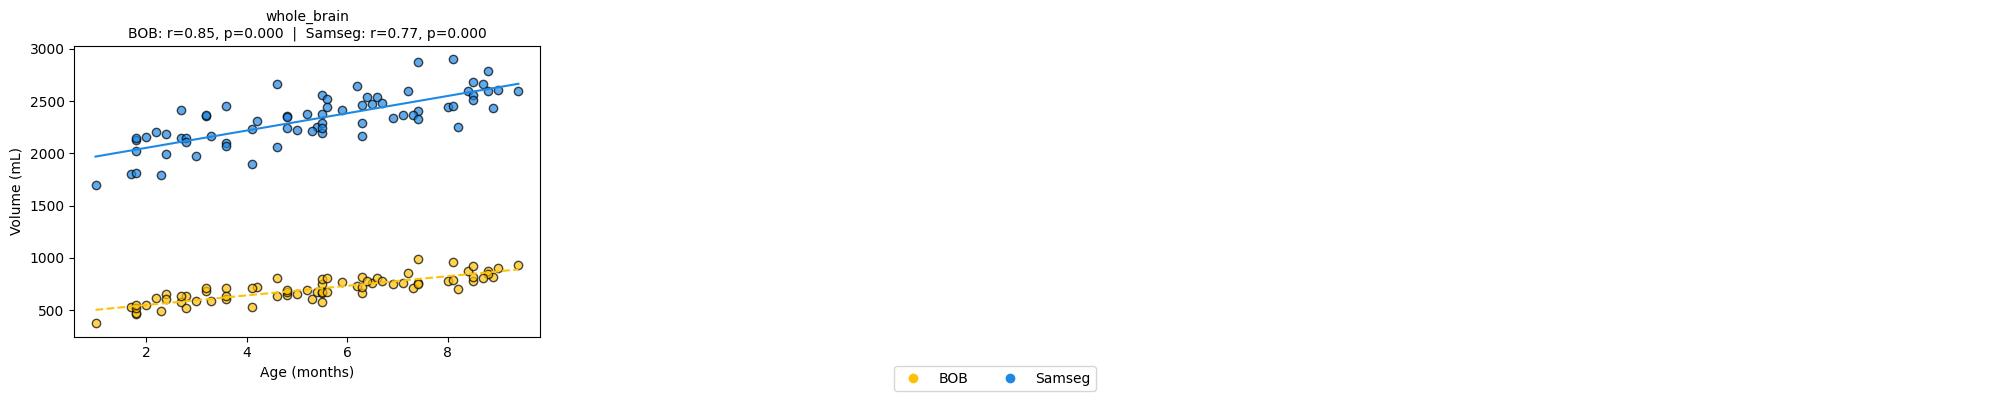

In [102]:
n = len(base_list)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 5, nrows * 4),
    sharex=True
)
axes = axes.flatten()

for idx, base in enumerate(base_list):
    ax = axes[idx]
    
    # Subset for this structure
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == base]
    ages = sub['age'].values
    
    # Grab volume columns
    vols_BOB = sub['volume_BOB'].values
    vols_Samseg = sub['volume_Samseg'].values
    
    # Scatter plot for each method
    ax.scatter(
        ages, vols_BOB,
        label='BOB',
        color=colors_seg[0],
        edgecolor='k',
        alpha=0.7
    )
    ax.scatter(
        ages, vols_Samseg,
        label='Samseg',
        color=colors_seg[1],
        edgecolor='k',
        alpha=0.7
    )
    
    # Fit regression line for BOB
    if len(ages) > 1:
        slope_bob, intercept_bob = np.polyfit(ages, vols_BOB, 1)
        x_line = np.linspace(ages.min(), ages.max(), 100)
        y_line_bob = slope_bob * x_line + intercept_bob
        ax.plot(
            x_line, y_line_bob,
            color=colors_seg[0], linestyle='--'
        )

    # Fit regression line for Samseg
    if len(ages) > 1:
        slope_ss, intercept_ss = np.polyfit(ages, vols_Samseg, 1)
        y_line_ss = slope_ss * x_line + intercept_ss
        ax.plot(
            x_line, y_line_ss,
            color=colors_seg[1], linestyle='-'
        )
    
    # Pearson correlations
    if len(ages) > 1:
        r_bob, p_bob = pearsonr(ages, vols_BOB)
        r_ss, p_ss = pearsonr(ages, vols_Samseg)
    else:
        r_bob = p_bob = r_ss = p_ss = np.nan

    ax.set_title(
        f"{base}\n"
        f"BOB: r={r_bob:.2f}, p={p_bob:.3f}  |  "
        f"Samseg: r={r_ss:.2f}, p={p_ss:.3f}",
        fontsize=10
    )
    
    # Only label x‐axis on the bottom row
    if idx // ncols == nrows - 1:
        ax.set_xlabel("Age (months)")
    # Only label y‐axis on the left column
    if idx % ncols == 0:
        ax.set_ylabel("Volume (mL)")

# Turn off any unused axes
for j in range(n, len(axes)):
    axes[j].axis('off')

# Single legend at bottom
handles = [
    plt.Line2D([], [], marker='o', linestyle='None',
               color=colors_seg[0], label='BOB'),
    plt.Line2D([], [], marker='o', linestyle='None',
               color=colors_seg[1], label='Samseg')
]
fig.legend(handles=handles, loc='lower center', ncol=2)

plt.tight_layout()
plt.show()

### BOB/SynthSeg over age

### Correlation with quality metrics

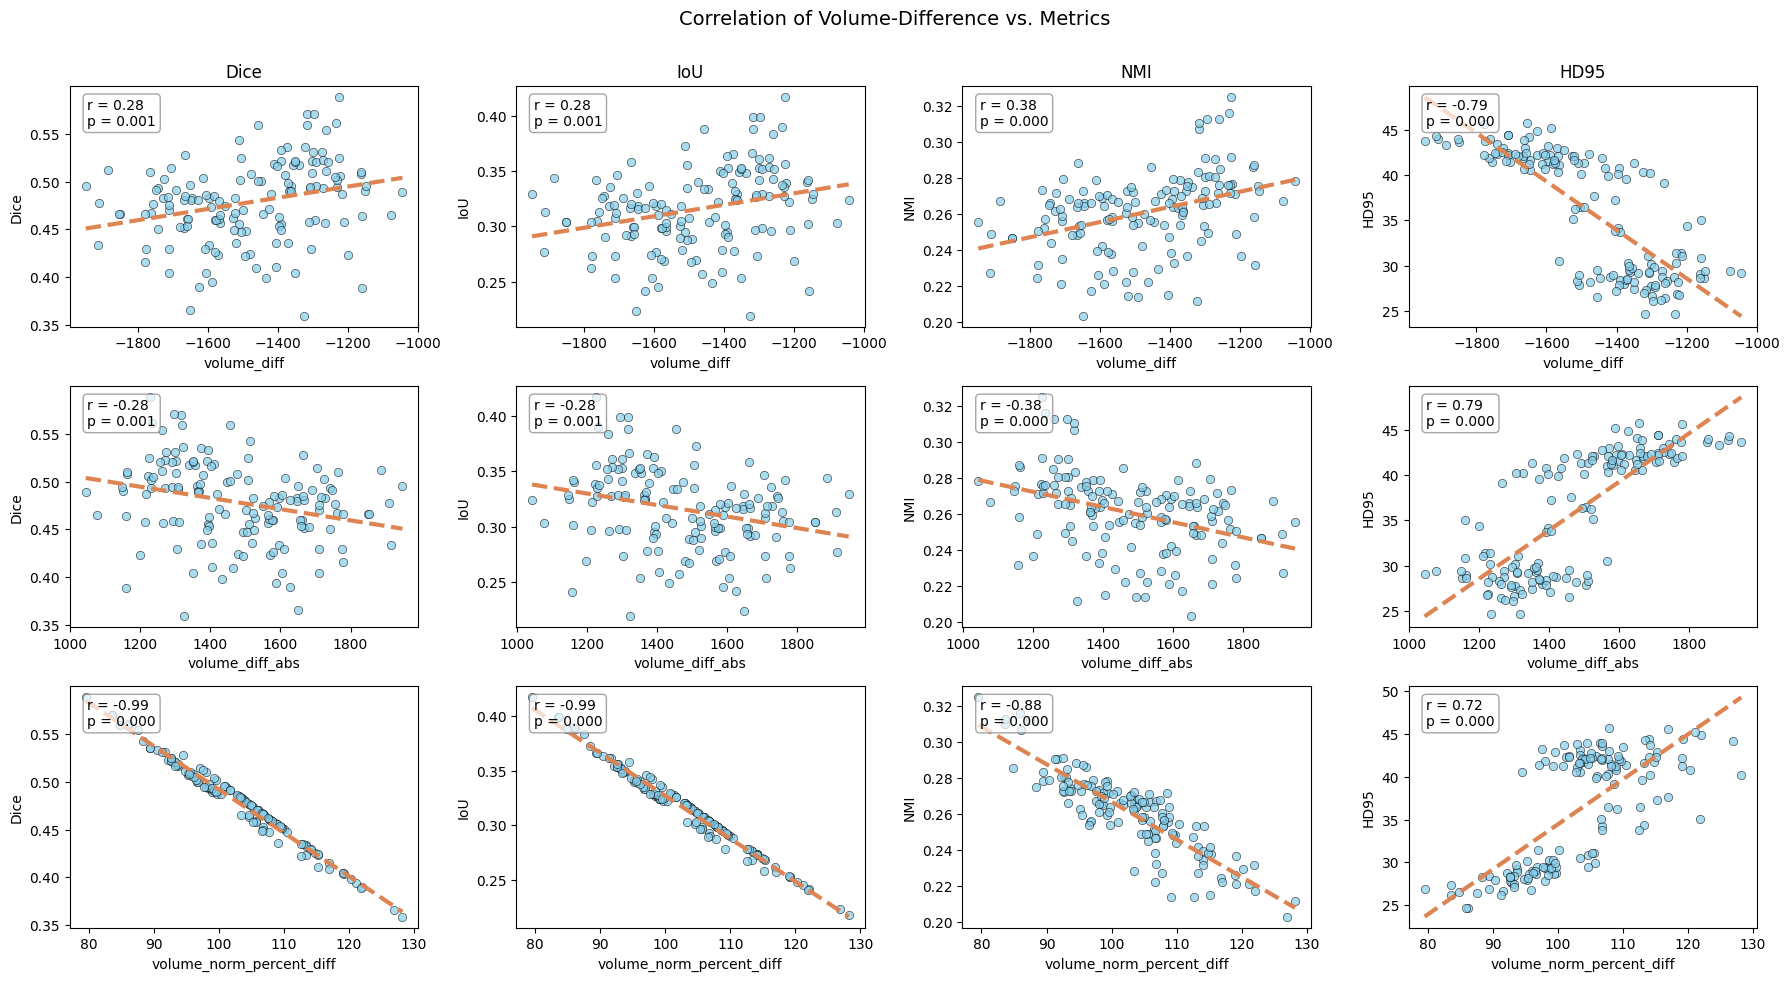

In [103]:
metrics = ["Dice", "IoU", "NMI", "HD95"]
x_cols  = ["volume_diff", "volume_diff_abs", "volume_norm_percent_diff"]

nrows = len(x_cols)   # 3
ncols = len(metrics)  # 4

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 4.5, nrows * 3.5),
    sharex=False
)

# Flatten axes for easy indexing if needed, but we'll also use a 2D index:
axes = np.array(axes)

for i, x_col in enumerate(x_cols):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        
        # Filter out NaNs
        sub = df_fd_volume_metrics.dropna(subset=[x_col, metric])
        x = sub[x_col].values
        y = sub[metric].values
        
        # Scatter plot
        sns.scatterplot(x=x, y=y, ax=ax, color='skyblue', edgecolor='k', alpha=0.7)

        
        # Fit regression line if ≥ 2 points
        if len(x) > 1:
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color="#dd8452", linestyle="--",lw=3)
        
        # Pearson correlation
        if len(x) > 1:
            r, p = pearsonr(x, y)
        else:
            r, p = np.nan, np.nan
        
        # Annotate r and p in top-left
        ax.text(
            0.05, 0.95,
            f"r = {r:.2f}\np = {p:.3f}",
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="gray",
                alpha=0.7
            )
        )
        
        # Only set titles on the top row
        if i == 0:
            ax.set_title(metric, fontsize=12)
        

        ax.set_ylabel(metric, fontsize=10)
        ax.set_xlabel(x_col, fontsize=10)

# Tight layout and super‐title
fig.suptitle("Correlation of Volume‐Difference vs. Metrics", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.975])
plt.show()


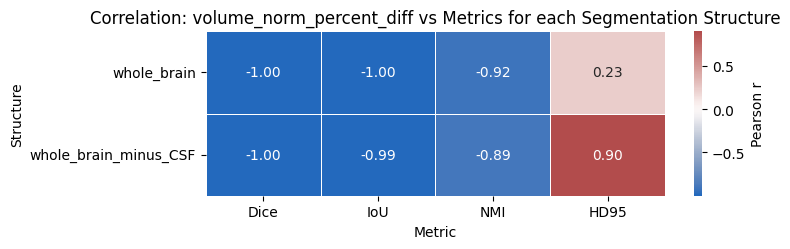

In [104]:
metrics = ["Dice", "IoU", "NMI", "HD95"]
x_col = "volume_norm_percent_diff"

structures = [name 
             for name in df_fd_volume_metrics[selected_name].unique() 
             if name != 'CSF']

corr_df = pd.DataFrame(index=structures, columns=metrics, dtype=float)

# fill in corr_df for each structure & each metric, compute Pearson r
for struct in structures:
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == struct]
    for metric in metrics:
        # Drop NaNs
        valid = sub[[x_col, metric]].dropna()
        if len(valid) > 1:
            r, _ = pearsonr(valid[x_col], valid[metric])
        else:
            r = np.nan
        corr_df.at[struct, metric] = r

corr_df = corr_df.sort_values(by="Dice", ascending=True)

# plot a heatmap of the correlation coefficients
plt.figure(figsize=(8, len(structures) * 0.3 + 2))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="vlag",     # diverging palette centered at 0
    center=0,
    cbar_kws={"label": "Pearson r"},
    linewidths=0.5
)
plt.title(f"Correlation: {x_col} vs Metrics for each Segmentation Structure")
plt.xlabel("Metric")
plt.ylabel("Structure")
plt.tight_layout()
plt.show()


## Fractal dimension

Select 'base_name' or 'name' depending on if you want to differ between the left and right side or not:

In [105]:
# selected_name = 'name' # for all names
selected_name = 'base_name' # for base names without Left/Right prefix

base_list = [name 
             for name in df_fd_volume_metrics[selected_name].unique() 
             if name not in ['CSF', 'whole_brain_minus_CSF']]
base_list.sort()

### BOB vs. SynthSeg

In [106]:
stats_list = []

for label in base_list:
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == label]
    if sub.empty:
        continue  # Skip if no data
    
    bob = sub['fd_BOB']
    samseg = sub['fd_Samseg']
    diff = bob - samseg
    
    mean_diff = diff.mean()
    sd_diff   = diff.std(ddof=1)
    t_stat, p_val = ttest_rel(bob, samseg)

    d_val = ut.cohen_d_paired(bob, samseg)
    
    stats_list.append({
        'name': label,
        'FD (BOB)': f"{bob.mean():.2f} ± {bob.std(ddof=1):.2f}",
        'FD (Samseg)': f"{samseg.mean():.2f} ± {samseg.std(ddof=1):.2f}",
        'FD (diff)': f"{mean_diff:.2f} ± {sd_diff:.2f}",
        'n': len(diff),
        'p-val': f"{p_val:.3f}",
        'd': f"{d_val:.2f}"
    })

df_stats = pd.DataFrame(stats_list)

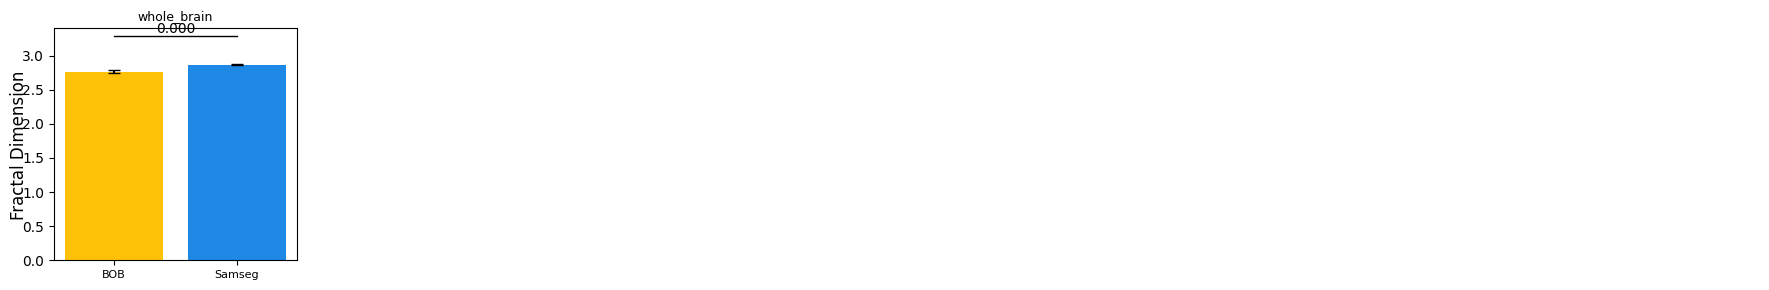

In [107]:
agg = df_fd_volume_metrics.groupby(selected_name)[['fd_BOB', 'fd_Samseg']].agg(['mean', 'std'])

n_pairs = len(base_list)
ncols = 6
nrows = int(np.ceil(n_pairs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3), sharey=True)
axes = axes.flatten()

for ax, label in zip(axes, base_list):
    if label not in agg.index:
        ax.axis('off')
        continue
    means = agg.loc[label][('fd_BOB', 'mean')], agg.loc[label][('fd_Samseg', 'mean')]
    stds  = agg.loc[label][('fd_BOB', 'std')],  agg.loc[label][('fd_Samseg', 'std')]

    x = np.arange(2)
    ax.bar(x, means, yerr=stds, capsize=4, color=colors_seg)
    ax.set_xticks(x)
    ax.set_xticklabels(['BOB', 'Samseg'], fontsize=8)
    ax.set_title(label, fontsize=9)

    # Significance p-value
    p = float(df_stats[df_stats['name'] == label]['p-val'].iloc[0])
    if p < 0.05:
        y0 = (max(means) + max(stds))*1.14
        ax.plot([x[0], x[1]], [y0, y0], color='black', linewidth=1)
        ax.text((x[0]+x[1])/2, y0 + 0.005, f"{p:.3f}", ha='center', va='bottom', fontsize=10)


# Turn off empty subplots
for ax in axes[n_pairs:]:
    ax.axis('off')

fig.supylabel("Fractal Dimension")
plt.setp(axes, ylim=(0, 3.4))
plt.tight_layout()
plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.show()

Showing the sign. differences after Bonferroni correction 

In [108]:
# number of paired tests
n_tests = len(df_stats)
alpha_corr = 0.05 / n_tests

df_stats['p_nominal'] = df_stats['p-val'].astype(float)
df_stats['sign_corr'] = df_stats['p_nominal'] < alpha_corr

print(f"Bonferroni α = {alpha_corr:.4f}")
df_stats.loc[df_stats['sign_corr'], ['name', 'FD (BOB)', 'FD (Samseg)', 'FD (diff)','n', 'p-val', 'd']]

Bonferroni α = 0.0500


,name,FD (BOB),FD (Samseg),FD (diff),n,p-val,d
0,whole_brain,2.77 ± 0.02,2.86 ± 0.01,-0.10 ± 0.01,71,0.000,-7.53


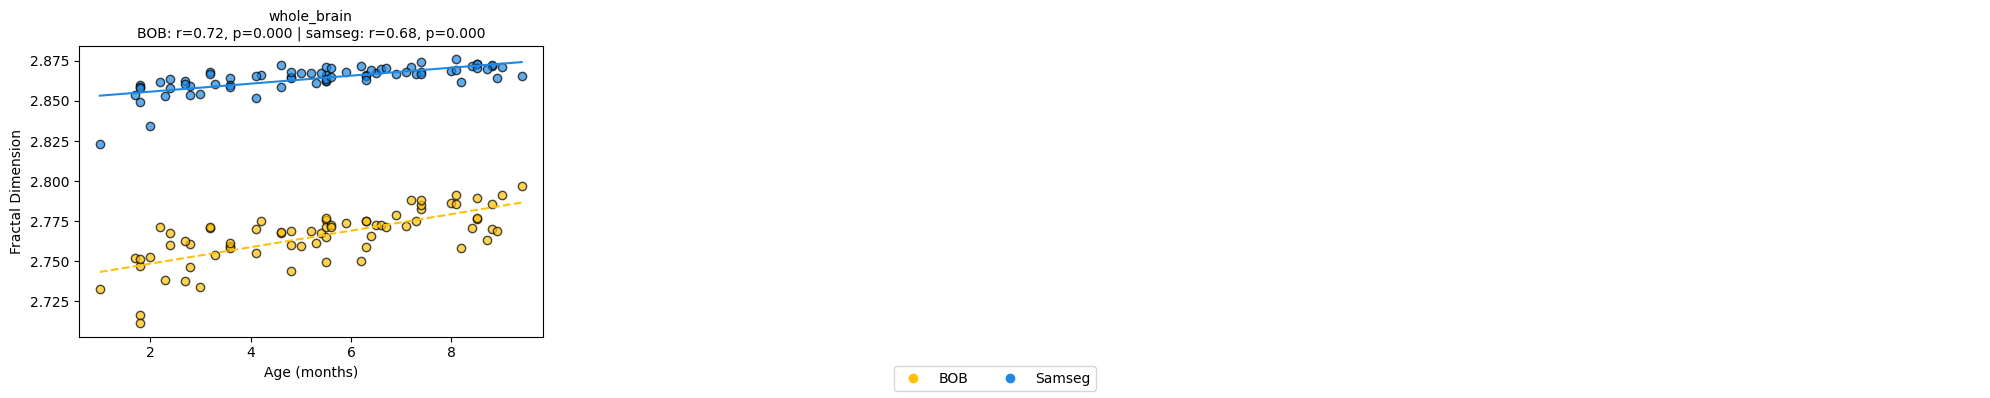

In [109]:
n = len(base_list)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 5, nrows * 4),
                         sharex=True)
axes = axes.flatten()

for idx, base in enumerate(base_list):
    ax = axes[idx]
    
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == base]
    ages = sub['age'].values
    
    fds_BOB = sub['fd_BOB'].values
    fds_samseg = sub['fd_Samseg'].values
    
    # Scatter plot for each method
    ax.scatter(ages, fds_BOB, label='BOB', color=colors_seg[0], edgecolor='k', alpha=0.7)
    ax.scatter(ages, fds_samseg, label='Samseg', color=colors_seg[1], edgecolor='k', alpha=0.7)
    
    # Fit regression line for BOB
    if len(ages) > 1:
        slope_bob, intercept_bob = np.polyfit(ages, fds_BOB, 1)
        x_line = np.linspace(ages.min(), ages.max(), 100)
        y_line_bob = slope_bob * x_line + intercept_bob
        ax.plot(x_line, y_line_bob, color=colors_seg[0], linestyle='--')

    # Fit regression line for samseg
    if len(ages) > 1:
        slope_fs, intercept_fs = np.polyfit(ages, fds_samseg, 1)
        y_line_fs = slope_fs * x_line + intercept_fs
        ax.plot(x_line, y_line_fs, color=colors_seg[1], linestyle='-')
    
    # Pearson correlations
    r_bob, p_bob = pearsonr(ages, fds_BOB)
    r_fs, p_fs = pearsonr(ages, fds_samseg)

    ax.set_title(f"{base}\nBOB: r={r_bob:.2f}, p={p_bob:.3f} | samseg: r={r_fs:.2f}, p={p_fs:.3f}", fontsize=10)
    
    if idx // ncols == nrows - 1:
        ax.set_xlabel("Age (months)")
    if idx % ncols == 0:
        ax.set_ylabel("Fractal Dimension")

# Turn off unused axes
for j in range(n, len(axes)):
    axes[j].axis('off')

# Add legend once
handles = [plt.Line2D([], [], marker='o', linestyle='None', color=colors_seg[0], label='BOB'),
           plt.Line2D([], [], marker='o', linestyle='None', color=colors_seg[1], label='Samseg')]
fig.legend(handles=handles, loc='lower center', ncol=2)

plt.tight_layout()
plt.show()

### BOB/SynthSeg over age

### Correlation with quality metrics

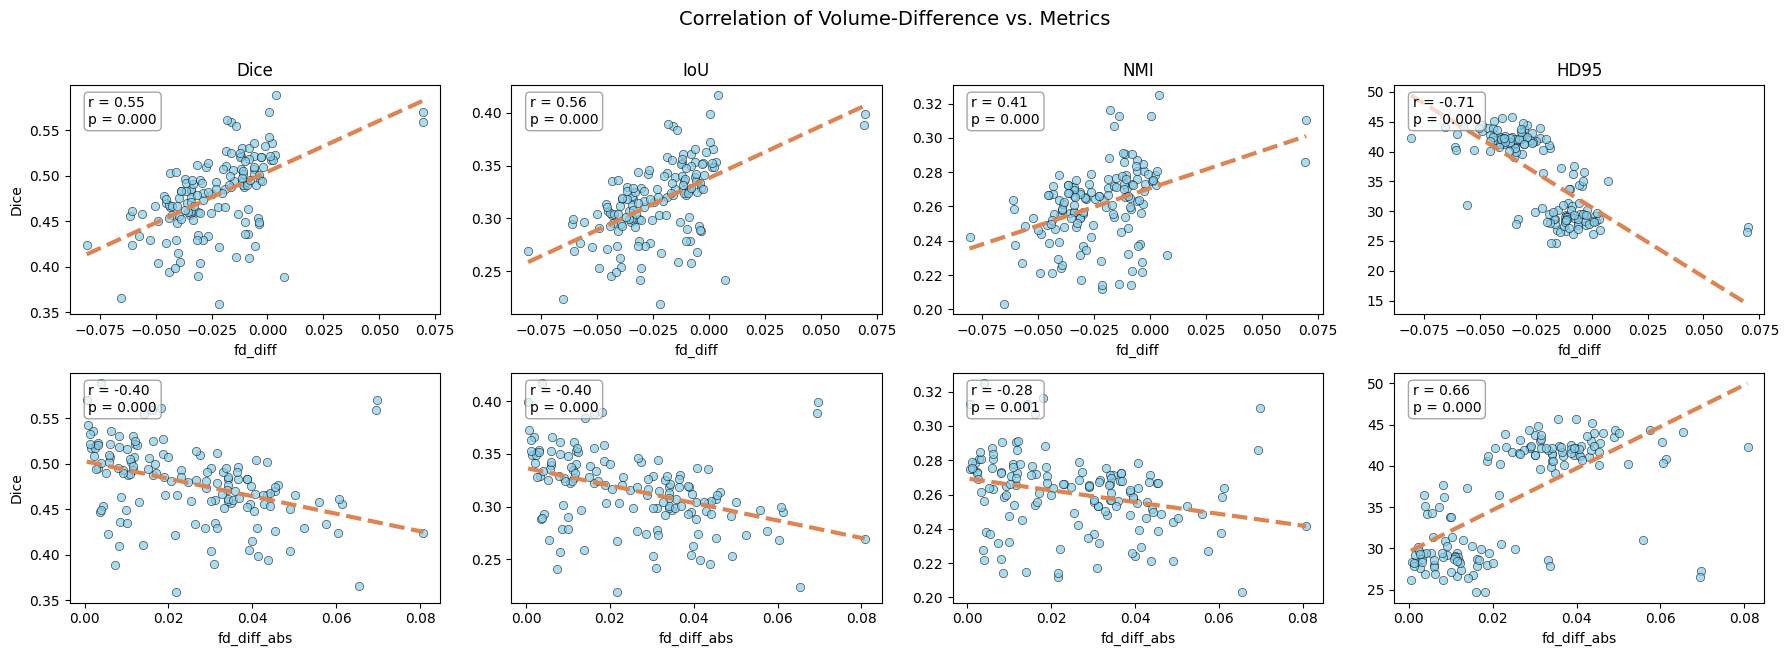

In [110]:
metrics = ["Dice", "IoU", "NMI", "HD95"]
x_cols  = ["fd_diff", "fd_diff_abs"]

nrows = len(x_cols)   
ncols = len(metrics) 

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 4.5, nrows * 3.5),
    sharex=False
)

# Flatten axes for easy indexing if needed, but we'll also use a 2D index:
axes = np.array(axes)

for i, x_col in enumerate(x_cols):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        
        # Filter out NaNs
        sub = df_fd_volume_metrics.dropna(subset=[x_col, metric])
        x = sub[x_col].values
        y = sub[metric].values
        
        # Scatter plot
        sns.scatterplot(x=x, y=y, ax=ax, color='skyblue', edgecolor='k', alpha=0.7)

        
        # Fit regression line if ≥ 2 points
        if len(x) > 1:
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color="#dd8452", linestyle="--",lw=3)
        
        # Pearson correlation
        if len(x) > 1:
            r, p = pearsonr(x, y)
        else:
            r, p = np.nan, np.nan
        
        # Annotate r and p in top-left
        ax.text(
            0.05, 0.95,
            f"r = {r:.2f}\np = {p:.3f}",
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="gray",
                alpha=0.7
            )
        )
        
        # Only set titles on the top row
        if i == 0:
            ax.set_title(metric, fontsize=12)
        
        # Only label y‐axis on the first column
        if j == 0:
            ax.set_ylabel(metric, fontsize=10)
        else:
            ax.set_ylabel("")
        

        ax.set_xlabel(x_col, fontsize=10)

# Tight layout and super‐title
fig.suptitle("Correlation of Volume‐Difference vs. Metrics", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.975])
plt.show()

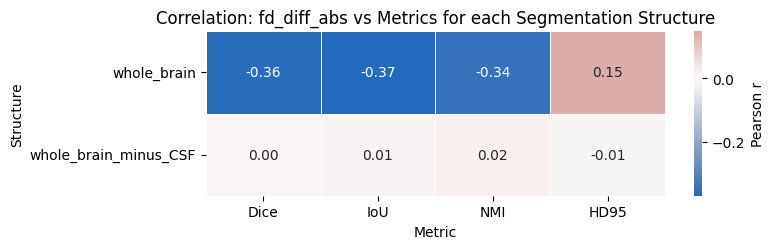

In [111]:
metrics = ["Dice", "IoU", "NMI", "HD95"]
x_col = "fd_diff_abs"

structures = [name 
             for name in df_fd_volume_metrics[selected_name].unique() 
             if name != 'CSF']

corr_df = pd.DataFrame(index=structures, columns=metrics, dtype=float)

# fill in corr_df for each structure & each metric, compute Pearson r
for struct in structures:
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == struct]
    for metric in metrics:
        # Drop NaNs
        valid = sub[[x_col, metric]].dropna()
        if len(valid) > 1:
            r, _ = pearsonr(valid[x_col], valid[metric])
        else:
            r = np.nan
        corr_df.at[struct, metric] = r

corr_df = corr_df.sort_values(by="Dice", ascending=True)

# plot a heatmap of the correlation coefficients
plt.figure(figsize=(8, len(structures) * 0.3 + 2))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="vlag",     # diverging palette centered at 0
    center=0,
    cbar_kws={"label": "Pearson r"},
    linewidths=0.5
)
plt.title(f"Correlation: {x_col} vs Metrics for each Segmentation Structure")
plt.xlabel("Metric")
plt.ylabel("Structure")
plt.tight_layout()
plt.show()

## Volume diff and FD diff correlation

/tmp/ipykernel_1032093/249210556.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


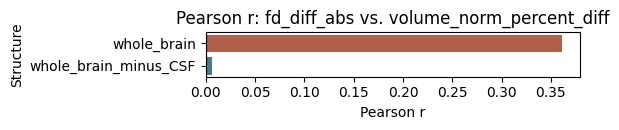

In [112]:
# selected_name = 'name' # for all names
selected_name = 'base_name' # for base names without Left/Right prefix

structures = [name 
             for name in df_fd_volume_metrics[selected_name].unique() 
             if name != 'CSF']

# for each structure, compute Pearson r between fd_diff_abs and volume_norm_percent_diff
corr_list = []
for struct in structures:
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == struct]
    sub = sub.dropna(subset=["fd_diff_abs", "volume_norm_percent_diff"])
    if len(sub) > 1:
        r, p = pearsonr(sub["volume_norm_percent_diff"], sub["fd_diff_abs"])
    else:
        r, p = np.nan, np.nan
    corr_list.append({"name": struct, "r": r, "p": p})

corr_df = pd.DataFrame(corr_list).set_index("name").sort_values("r", ascending=False)
palette = sns.diverging_palette(20, 220, n=len(corr_df), as_cmap=False)

# barplot of correlation coefficients
plt.figure(figsize=(6, len(corr_df) * 0.2 + 1))
sns.barplot(
    x="r",
    y=corr_df.index,
    data=corr_df.reset_index(),
    palette=palette,
)
plt.axvline(0, color="k", linewidth=0.8)
plt.title("Pearson r: fd_diff_abs vs. volume_norm_percent_diff")
plt.xlabel("Pearson r")
plt.ylabel("Structure")
plt.tight_layout()
plt.show()